# 🌾 Seasonal Agriculture Performance Analysis
**VOIS AICTE Batch1 2026-2027 | Major Project**

---

## Project Overview
This notebook presents a comprehensive analysis of seasonal agricultural performance across different states, crops, and farming conditions in India. The goal is to identify meaningful patterns, trends, relationships and differences in agricultural performance across seasons.

### End Users of This Analysis:
- **Farmers** — To decide which crop and season maximizes profit
- **Government / Agriculture Ministry** — For evidence-based policy making and resource allocation
- **Agricultural Scientists** — To study seasonal environmental impacts
- **NGOs & Rural Development Bodies** — For supporting sustainable farming practices
- **Agri-business Investors** — To identify high-return crop-region combinations
- **Insurance Companies** — For crop risk assessment and premium planning

## Table of Contents
1. [Import Libraries](#1)
2. [Load & Understand the Dataset](#2)
3. [Data Cleaning & Preparation](#3)
4. [Seasonal Performance Analysis](#4)
5. [Crop-wise Analysis](#5)
6. [Environmental Conditions Analysis](#6)
7. [Resource Usage Analysis](#7)
8. [State-wise Regional Analysis](#8)
9. [Correlation & Relationship Analysis](#9)
10. [Loss Farm Investigation](#10)
11. [Key Questions Answered](#11)
12. [Conclusions & Recommendations](#12)

<a id='1'></a>
## 1. Import Libraries

In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Global plot styling
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'

SEASON_COLORS = {'Kharif': '#2ecc71', 'Rabi': '#3498db', 'Zaid': '#e74c3c'}

print(' All libraries imported successfully')

 All libraries imported successfully


<a id='2'></a>
## 2. Load & Understand the Dataset

In [54]:
df = pd.read_csv('seasonal_agriculture_performance_dataset.csv')
print('Dataset Shape:', df.shape)
print(f'Total Records: {len(df):,}')
print(f'Total Features: {df.shape[1]}')
df.head()

Dataset Shape: (4000, 28)
Total Records: 4,000
Total Features: 28


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [55]:
print('=== DATASET INFORMATION ===')
df.info()

=== DATASET INFORMATION ===
<class 'pandas.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   str    
 1   State                          4000 non-null   str    
 2   District                       4000 non-null   str    
 3   Crop                           4000 non-null   str    
 4   Season                         4000 non-null   str    
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 

In [56]:
print('=== STATISTICAL SUMMARY ===')
df.describe().round(2)

=== STATISTICAL SUMMARY ===


,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
count,4000.00,3952.00,4000.00,4000.00,4000.00,4000.00,3960.00,4000.00,4000.00,4000.00,...,4000.00,3968.00,4000.00,4000.00,4000.00,4000.00,4000.00,4000.00,4000.00,4000.00
mean,7.89,601.15,26.82,63.21,7.32,6.70,26.51,120.25,57.78,104.76,...,0.83,5.27,43.25,44714.17,526303.58,637860.05,111556.46,6045.57,5.39,46.37
std,4.22,288.93,3.82,11.96,1.12,0.64,6.71,31.22,17.02,27.74,...,0.10,13.36,126.88,30266.16,294419.14,636974.71,545081.89,5572.94,8.84,12.42
min,0.50,80.00,16.20,25.00,3.50,5.20,8.00,40.00,15.00,30.00,...,0.65,0.30,0.15,2594.00,26826.00,6107.00,-1019223.00,128.00,0.14,5.00
25%,4.26,370.20,23.90,54.78,6.60,6.26,21.70,98.50,46.20,86.20,...,0.74,1.05,5.02,21429.25,274577.50,207517.25,-148731.75,2268.75,1.66,37.30
50%,7.90,582.00,26.90,63.00,7.30,6.69,26.40,120.10,57.50,105.10,...,0.83,1.74,11.77,25913.00,519082.50,456830.50,3673.00,4435.00,2.94,46.40
75%,11.65,834.95,29.60,71.90,8.10,7.14,31.30,141.22,69.40,123.60,...,0.91,2.84,24.36,68279.00,761996.50,836874.75,216187.75,7829.75,5.15,54.90
max,15.00,1395.20,39.70,95.00,11.00,8.40,47.00,220.00,120.00,200.00,...,1.00,101.44,1424.40,131240.00,1349990.00,5080900.00,4345421.00,40902.00,79.80,88.90


In [57]:
print('=== UNIQUE VALUES IN CATEGORICAL COLUMNS ===')
print(f'Seasons  : {df["Season"].unique()}')
print(f'Crops    : {df["Crop"].unique()}')
print(f'States   : {df["State"].unique()}')
print(f'Irrigation: {df["Irrigation_Method"].unique()}')
print()
print('=== SEASON DISTRIBUTION ===')
print(df['Season'].value_counts())

=== UNIQUE VALUES IN CATEGORICAL COLUMNS ===
Seasons  : <StringArray>
['Kharif', 'Rabi', 'Zaid']
Length: 3, dtype: str
Crops    : <StringArray>
[    'Wheat',     'Maize',    'Pulses',      'Rice',    'Cotton',    'Chilli',
 'Groundnut', 'Sugarcane']
Length: 8, dtype: str
States   : <StringArray>
['Andhra Pradesh',    'Maharashtra',      'Telangana',      'Karnataka',
        'Gujarat',     'Tamil Nadu',         'Punjab', 'Madhya Pradesh']
Length: 8, dtype: str
Irrigation: <StringArray>
['Drip', 'Flood', 'Rainfed', 'Sprinkler']
Length: 4, dtype: str

=== SEASON DISTRIBUTION ===
Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64


**Dataset Overview:**
- The dataset contains **4,000 farm records** across **28 features**
- Covers **3 Indian agricultural seasons**: Kharif (monsoon), Rabi (winter), Zaid (summer)
- Spans **8 major states** and **8 crop types**
- Features cover environmental conditions, soil properties, resource usage, and economic outcomes
- Kharif has the most records (1,779) as it is India's primary crop season

<a id='3'></a>
## 3. Data Cleaning & Preparation

In [58]:
print('=== MISSING VALUES ===')
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Percentage (%)': missing_pct})
missing_df[missing_df['Missing Count'] > 0]

=== MISSING VALUES ===


,Missing Count,Percentage (%)
Rainfall_mm,48,1.2
Soil_Moisture_pct,40,1.0
Yield_Tonnes_Ha,32,0.8


In [59]:
# Impute missing values with season-wise median (more accurate than global median)
cols_with_missing = ['Rainfall_mm', 'Soil_Moisture_pct', 'Yield_Tonnes_Ha']

for col in cols_with_missing:
    df[col] = df.groupby('Season')[col].transform(lambda x: x.fillna(x.median()))

print(' Missing values imputed using season-wise median')
print('Remaining missing values:', df.isnull().sum().sum())

 Missing values imputed using season-wise median
Remaining missing values: 0


In [60]:
# Outlier Detection using IQR method
numeric_cols = ['Yield_Tonnes_Ha', 'Profit_INR', 'Rainfall_mm', 'Fertilizer_kg_ha']

print('=== OUTLIER DETECTION (IQR Method) ===')
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)].shape[0]
    print(f'{col}: {outliers} outliers (kept — represent real farm variation)')

print()
print('Note: Outliers retained as they represent genuine agricultural variation (e.g., Sugarcane has naturally high yield)')

=== OUTLIER DETECTION (IQR Method) ===
Yield_Tonnes_Ha: 302 outliers (kept — represent real farm variation)
Profit_INR: 404 outliers (kept — represent real farm variation)
Rainfall_mm: 0 outliers (kept — represent real farm variation)
Fertilizer_kg_ha: 15 outliers (kept — represent real farm variation)

Note: Outliers retained as they represent genuine agricultural variation (e.g., Sugarcane has naturally high yield)


In [61]:
# Feature Engineering — add useful derived columns
df['Profit_Category'] = df['Profit_INR'].apply(lambda x: 'Profitable' if x > 0 else 'Loss')
df['Yield_Category'] = pd.qcut(df['Yield_Tonnes_Ha'], q=3, labels=['Low', 'Medium', 'High'])
df['Cost_Per_Hectare'] = df['Total_Cost_INR'] / df['Farm_Area_Hectares']
df['Revenue_Per_Hectare'] = df['Revenue_INR'] / df['Farm_Area_Hectares']

print('Feature engineering done')
print('New columns added: Profit_Category, Yield_Category, Cost_Per_Hectare, Revenue_Per_Hectare')
print()
print('Profit Category Distribution:')
print(df['Profit_Category'].value_counts())

Feature engineering done
New columns added: Profit_Category, Yield_Category, Cost_Per_Hectare, Revenue_Per_Hectare

Profit Category Distribution:
Profit_Category
Profitable    2034
Loss          1966
Name: count, dtype: int64


**Data Cleaning Summary:**
- **3 columns** had missing values: `Rainfall_mm` (48), `Soil_Moisture_pct` (40), `Yield_Tonnes_Ha` (32)
- Imputed using **season-wise median** to preserve seasonal patterns
- Outliers were **retained** as they represent genuine agricultural variation (Sugarcane naturally has very high yield)
- Engineered 4 new features for richer analysis

<a id='4'></a>
## 4. Seasonal Performance Analysis
**Key Question: How does agricultural performance vary across Kharif, Rabi, and Zaid seasons?**

In [62]:
season_stats = df.groupby('Season')[['Yield_Tonnes_Ha','Profit_INR','Revenue_INR','Total_Cost_INR']].mean().round(2)
print('=== AVERAGE PERFORMANCE BY SEASON ===')
season_stats

=== AVERAGE PERFORMANCE BY SEASON ===


,Yield_Tonnes_Ha,Profit_INR,Revenue_INR,Total_Cost_INR
Season,,,,
Kharif,5.63,178914.65,710719.06,531804.41
Rabi,5.04,87689.47,601526.05,513836.58
Zaid,4.64,-24804.82,519171.90,543976.73


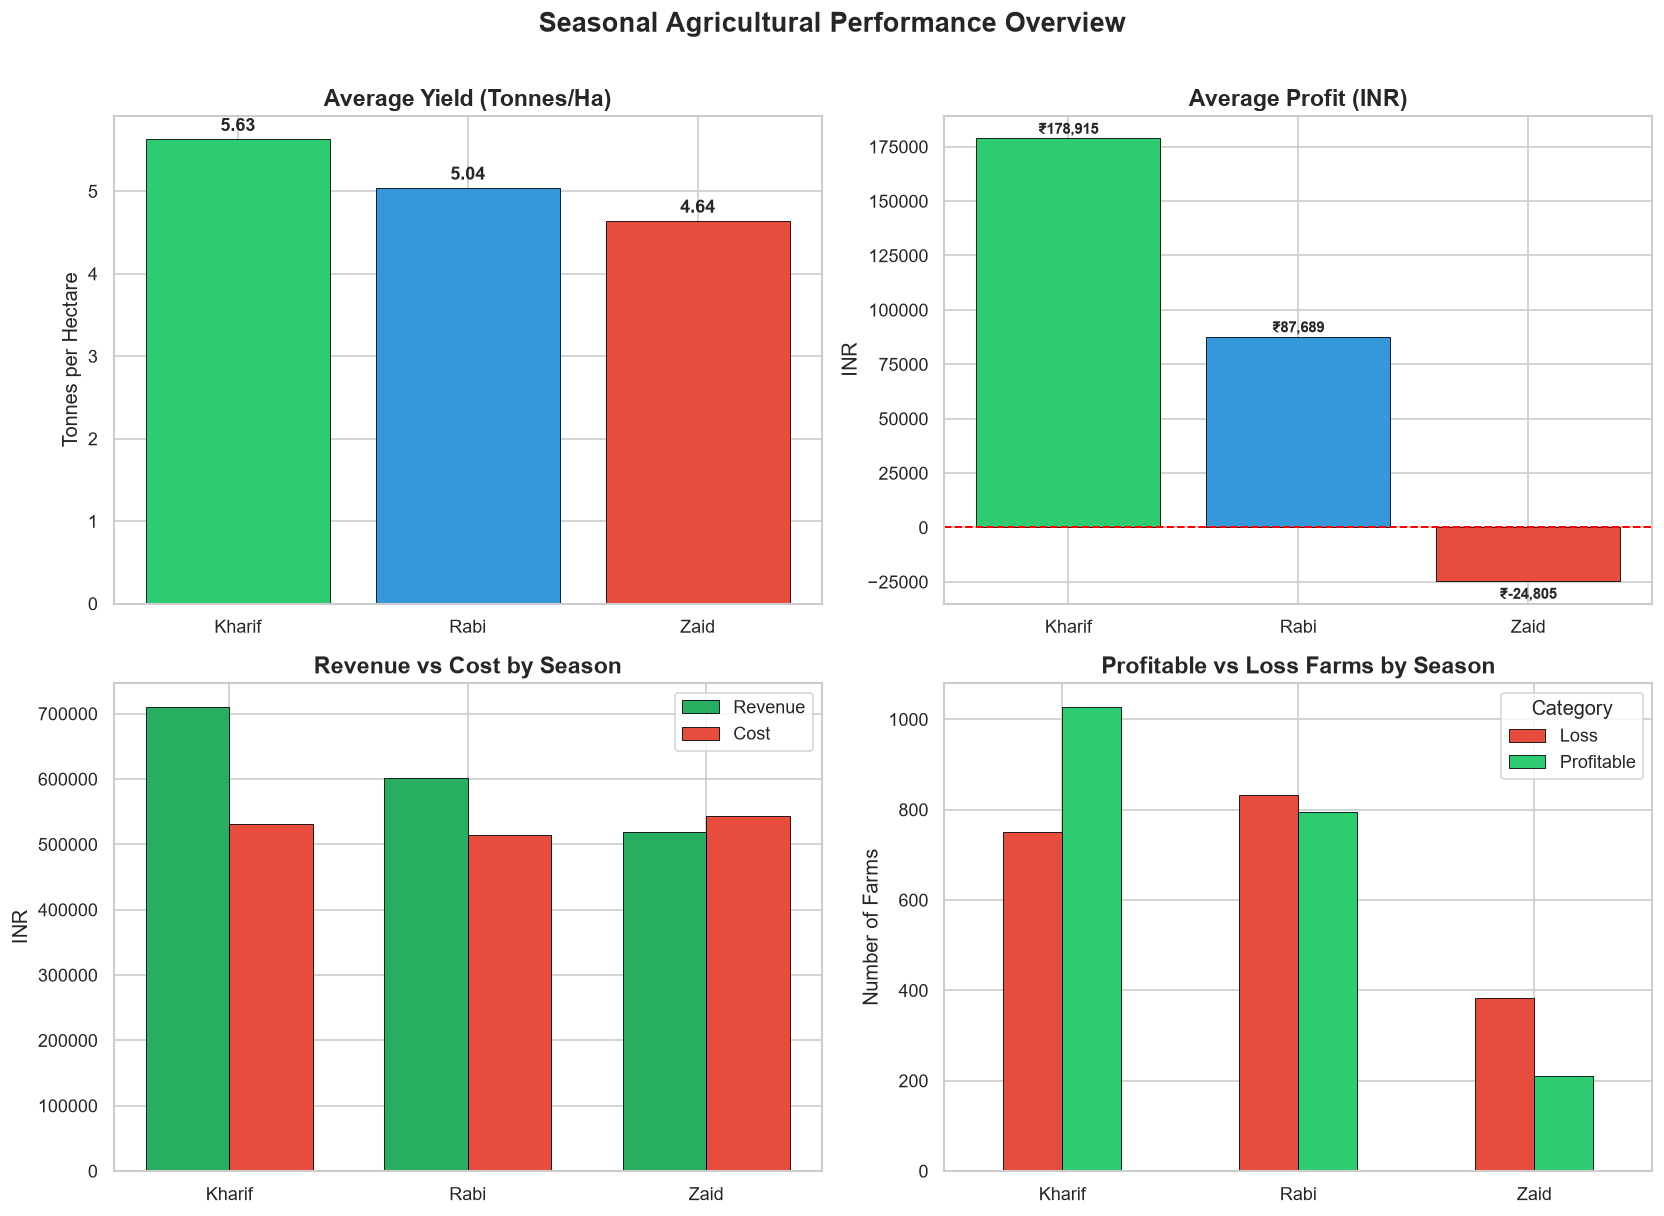


 Observation:
• Kharif season has the highest average yield (5.64 t/ha) and profit (₹1,78,915)
• Zaid season shows NEGATIVE average profit (-₹24,805) — a critical finding
• Rabi is moderate — decent yield but significantly lower profit than Kharif


In [63]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Seasonal Agricultural Performance Overview', fontsize=16, fontweight='bold', y=1.01)

seasons = ['Kharif', 'Rabi', 'Zaid']
colors = [SEASON_COLORS[s] for s in seasons]

# Plot 1 - Avg Yield
ax1 = axes[0, 0]
vals = [season_stats.loc[s, 'Yield_Tonnes_Ha'] for s in seasons]
bars = ax1.bar(seasons, vals, color=colors, edgecolor='black', linewidth=0.5)
ax1.set_title('Average Yield (Tonnes/Ha)')
ax1.set_ylabel('Tonnes per Hectare')
for bar, val in zip(bars, vals):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, f'{val:.2f}', ha='center', fontweight='bold')

# Plot 2 - Avg Profit
ax2 = axes[0, 1]
vals2 = [season_stats.loc[s, 'Profit_INR'] for s in seasons]
bars2 = ax2.bar(seasons, vals2, color=colors, edgecolor='black', linewidth=0.5)
ax2.set_title('Average Profit (INR)')
ax2.set_ylabel('INR')
ax2.axhline(0, color='red', linestyle='--', linewidth=1.2)
for bar, val in zip(bars2, vals2):
    ypos = bar.get_height() + 2000 if val >= 0 else bar.get_height() - 8000
    ax2.text(bar.get_x() + bar.get_width()/2, ypos, f'₹{val:,.0f}', ha='center', fontweight='bold', fontsize=9)

# Plot 3 - Revenue vs Cost
ax3 = axes[1, 0]
x = np.arange(len(seasons))
w = 0.35
rev = [season_stats.loc[s, 'Revenue_INR'] for s in seasons]
cost = [season_stats.loc[s, 'Total_Cost_INR'] for s in seasons]
ax3.bar(x - w/2, rev, w, label='Revenue', color='#27ae60', edgecolor='black', linewidth=0.5)
ax3.bar(x + w/2, cost, w, label='Cost', color='#e74c3c', edgecolor='black', linewidth=0.5)
ax3.set_xticks(x)
ax3.set_xticklabels(seasons)
ax3.set_title('Revenue vs Cost by Season')
ax3.set_ylabel('INR')
ax3.legend()

# Plot 4 - Profitable vs Loss farms per season
ax4 = axes[1, 1]
profit_counts = df.groupby(['Season', 'Profit_Category']).size().unstack(fill_value=0)
profit_counts.plot(kind='bar', ax=ax4, color=['#e74c3c', '#2ecc71'], edgecolor='black', linewidth=0.5)
ax4.set_title('Profitable vs Loss Farms by Season')
ax4.set_ylabel('Number of Farms')
ax4.set_xlabel('')
ax4.tick_params(axis='x', rotation=0)
ax4.legend(title='Category')

plt.tight_layout()
plt.savefig('plot1_seasonal_overview.png', bbox_inches='tight', dpi=120)
plt.show()
print('\n Observation:')
print('• Kharif season has the highest average yield (5.64 t/ha) and profit (₹1,78,915)')
print('• Zaid season shows NEGATIVE average profit (-₹24,805) — a critical finding')
print('• Rabi is moderate — decent yield but significantly lower profit than Kharif')

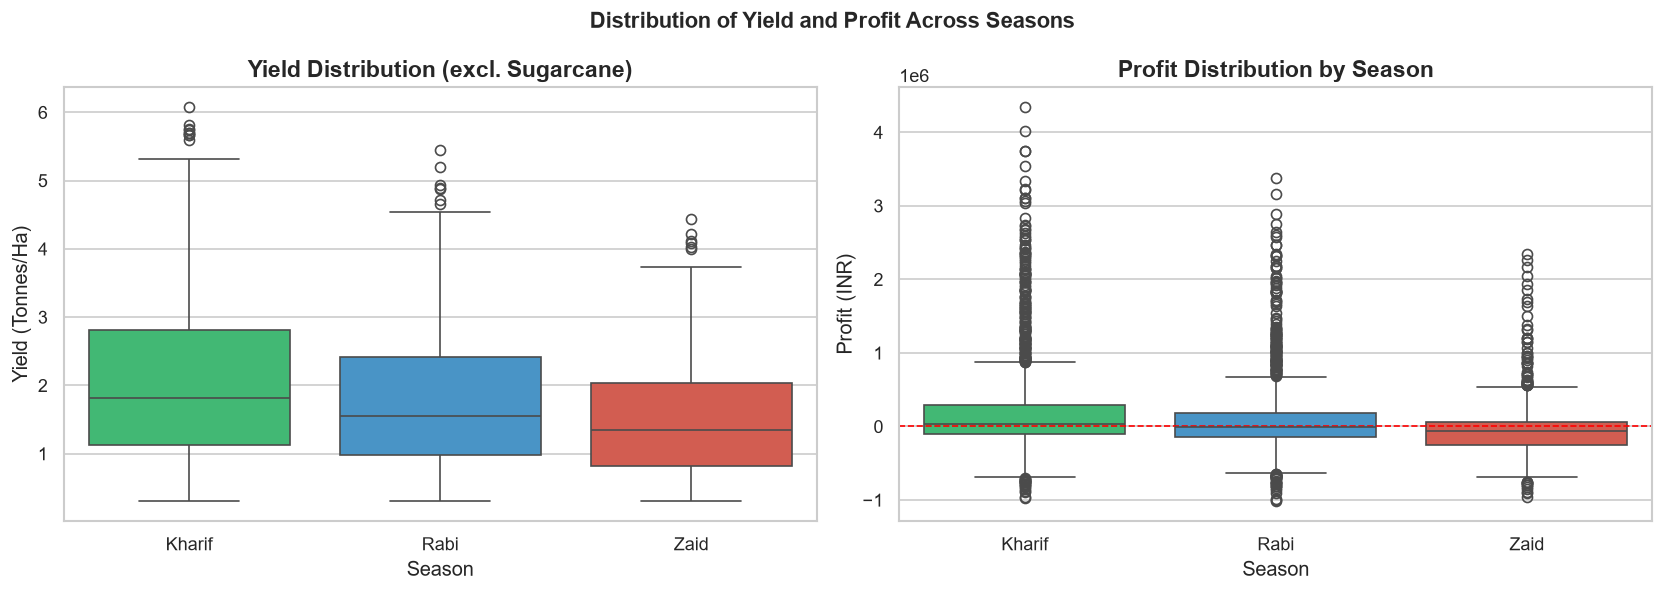


 Observation:
• Kharif shows highest median yield and widest profit spread
• Zaid has many farms below the ₹0 line — structural profitability issue
• Rabi has a tightly clustered, moderate profit range


In [64]:
# Yield distribution by season - Boxplot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribution of Yield and Profit Across Seasons', fontweight='bold')

# Exclude Sugarcane for yield boxplot (extreme outlier - distorts scale)
df_no_sc = df[df['Crop'] != 'Sugarcane']

sns.boxplot(data=df_no_sc, x='Season', y='Yield_Tonnes_Ha', palette=SEASON_COLORS,
            order=['Kharif','Rabi','Zaid'], ax=axes[0])
axes[0].set_title('Yield Distribution (excl. Sugarcane)')
axes[0].set_ylabel('Yield (Tonnes/Ha)')

sns.boxplot(data=df, x='Season', y='Profit_INR', palette=SEASON_COLORS,
            order=['Kharif','Rabi','Zaid'], ax=axes[1])
axes[1].set_title('Profit Distribution by Season')
axes[1].set_ylabel('Profit (INR)')
axes[1].axhline(0, color='red', linestyle='--', linewidth=1)

plt.tight_layout()
plt.savefig('plot2_distribution.png', bbox_inches='tight', dpi=120)
plt.show()
print('\n Observation:')
print('• Kharif shows highest median yield and widest profit spread')
print('• Zaid has many farms below the ₹0 line — structural profitability issue')
print('• Rabi has a tightly clustered, moderate profit range')

In [65]:
# Statistical test - ANOVA: Is there a significant difference in yield across seasons?
kharif_yield = df[df['Season'] == 'Kharif']['Yield_Tonnes_Ha']
rabi_yield   = df[df['Season'] == 'Rabi']['Yield_Tonnes_Ha']
zaid_yield   = df[df['Season'] == 'Zaid']['Yield_Tonnes_Ha']

f_stat, p_value = stats.f_oneway(kharif_yield, rabi_yield, zaid_yield)

print('=== ONE-WAY ANOVA TEST ===')
print('Hypothesis: Mean yield is equal across all seasons (H0)')
print(f'F-statistic : {f_stat:.4f}')
print(f'P-value     : {p_value:.6f}')
print()
if p_value < 0.05:
    print(' Result: p < 0.05 → Reject H0')
    print('   There IS a statistically significant difference in yield across seasons.')
else:
    print(' Result: p >= 0.05 → Fail to reject H0')

=== ONE-WAY ANOVA TEST ===
Hypothesis: Mean yield is equal across all seasons (H0)
F-statistic : 1.5538
P-value     : 0.211563

 Result: p >= 0.05 → Fail to reject H0


<a id='5'></a>
## 5. Crop-wise Analysis
**Key Question: Which crops perform best in which seasons? Which crops are causing losses?**

In [66]:
crop_profit = df.groupby('Crop')['Profit_INR'].mean().sort_values(ascending=False).round(0)
print('=== AVERAGE PROFIT BY CROP ===')
for crop, profit in crop_profit.items():
    status = '✅ Profitable' if profit > 0 else '❌ Loss'
    print(f'{crop:12s}: ₹{profit:>10,.0f}  {status}')

=== AVERAGE PROFIT BY CROP ===
Sugarcane   : ₹   817,188  ✅ Profitable
Chilli      : ₹   750,878  ✅ Profitable
Cotton      : ₹   124,547  ✅ Profitable
Groundnut   : ₹    44,858  ✅ Profitable
Pulses      : ₹    -4,238  ❌ Loss
Maize       : ₹   -83,978  ❌ Loss
Rice        : ₹  -102,214  ❌ Loss
Wheat       : ₹  -123,398  ❌ Loss


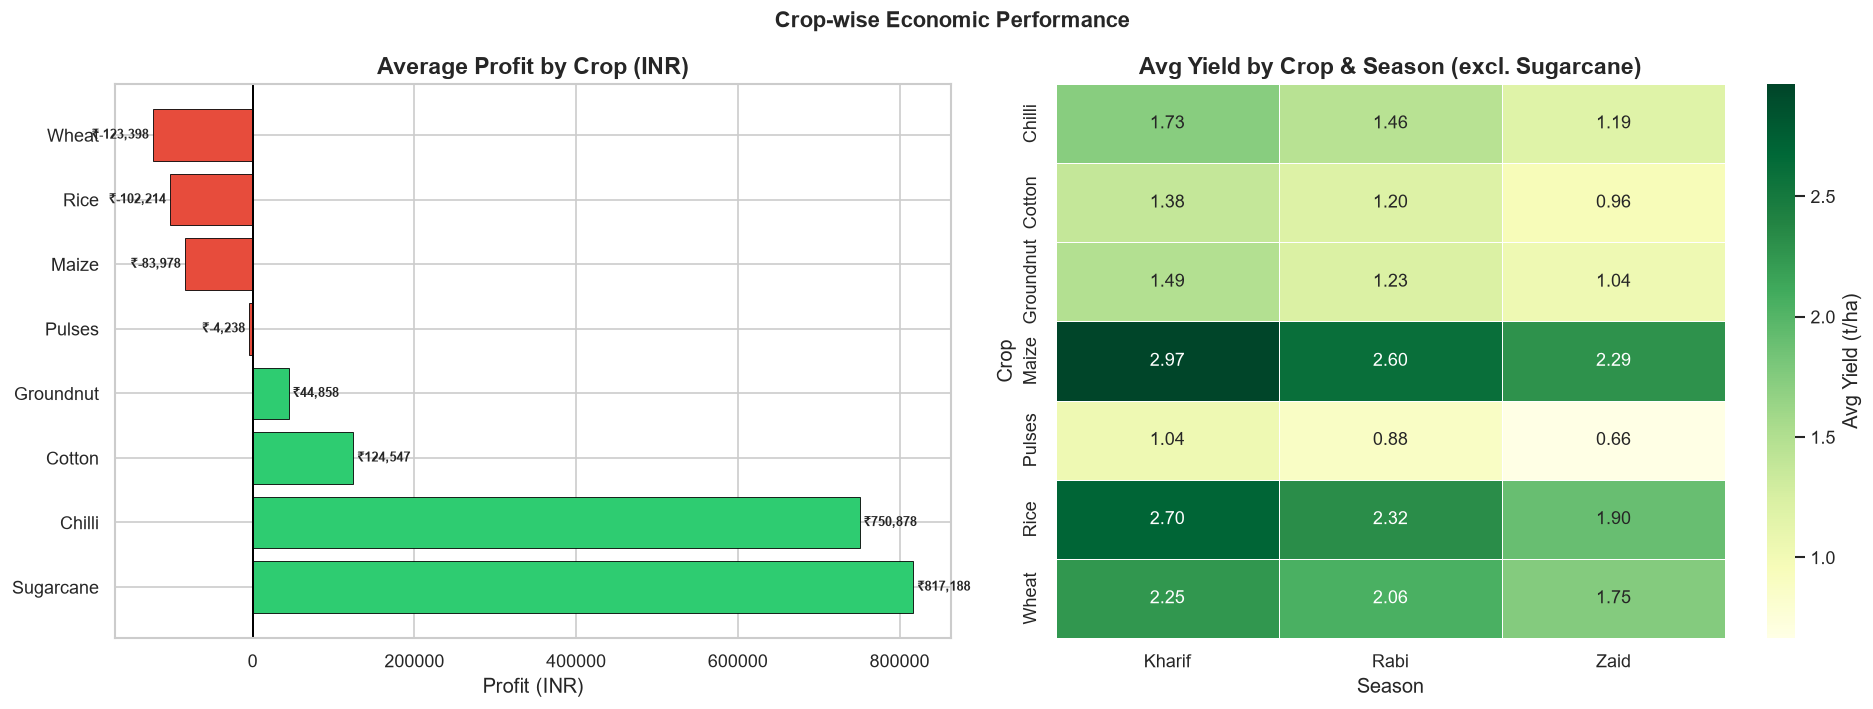


 Observation:
• Sugarcane and Chilli are the only consistently profitable crops
• Rice, Wheat, Maize show NEGATIVE average profit — staple crops are uneconomical
• Kharif universally outperforms Rabi and Zaid across all crops


In [67]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Crop-wise Economic Performance', fontweight='bold')

# Crop Profit Bar
crops = crop_profit.index.tolist()
profits = crop_profit.values
bar_colors = ['#2ecc71' if p > 0 else '#e74c3c' for p in profits]

axes[0].barh(crops, profits, color=bar_colors, edgecolor='black', linewidth=0.5)
axes[0].axvline(0, color='black', linewidth=1.2)
axes[0].set_title('Average Profit by Crop (INR)')
axes[0].set_xlabel('Profit (INR)')
for i, (crop, val) in enumerate(zip(crops, profits)):
    xpos = val + 5000 if val >= 0 else val - 5000
    ha = 'left' if val >= 0 else 'right'
    axes[0].text(xpos, i, f'₹{val:,.0f}', va='center', ha=ha, fontsize=8, fontweight='bold')

# Crop-Season Yield Heatmap
pivot = df.groupby(['Crop', 'Season'])['Yield_Tonnes_Ha'].mean().unstack()
# Separate Sugarcane for scale reasons
pivot_no_sc = pivot.drop('Sugarcane', errors='ignore')
sns.heatmap(pivot_no_sc, annot=True, fmt='.2f', cmap='YlGn', ax=axes[1],
            linewidths=0.5, cbar_kws={'label': 'Avg Yield (t/ha)'})
axes[1].set_title('Avg Yield by Crop & Season (excl. Sugarcane)')

plt.tight_layout()
plt.savefig('plot3_crop_analysis.png', bbox_inches='tight', dpi=120)
plt.show()
print('\n Observation:')
print('• Sugarcane and Chilli are the only consistently profitable crops')
print('• Rice, Wheat, Maize show NEGATIVE average profit — staple crops are uneconomical')
print('• Kharif universally outperforms Rabi and Zaid across all crops')

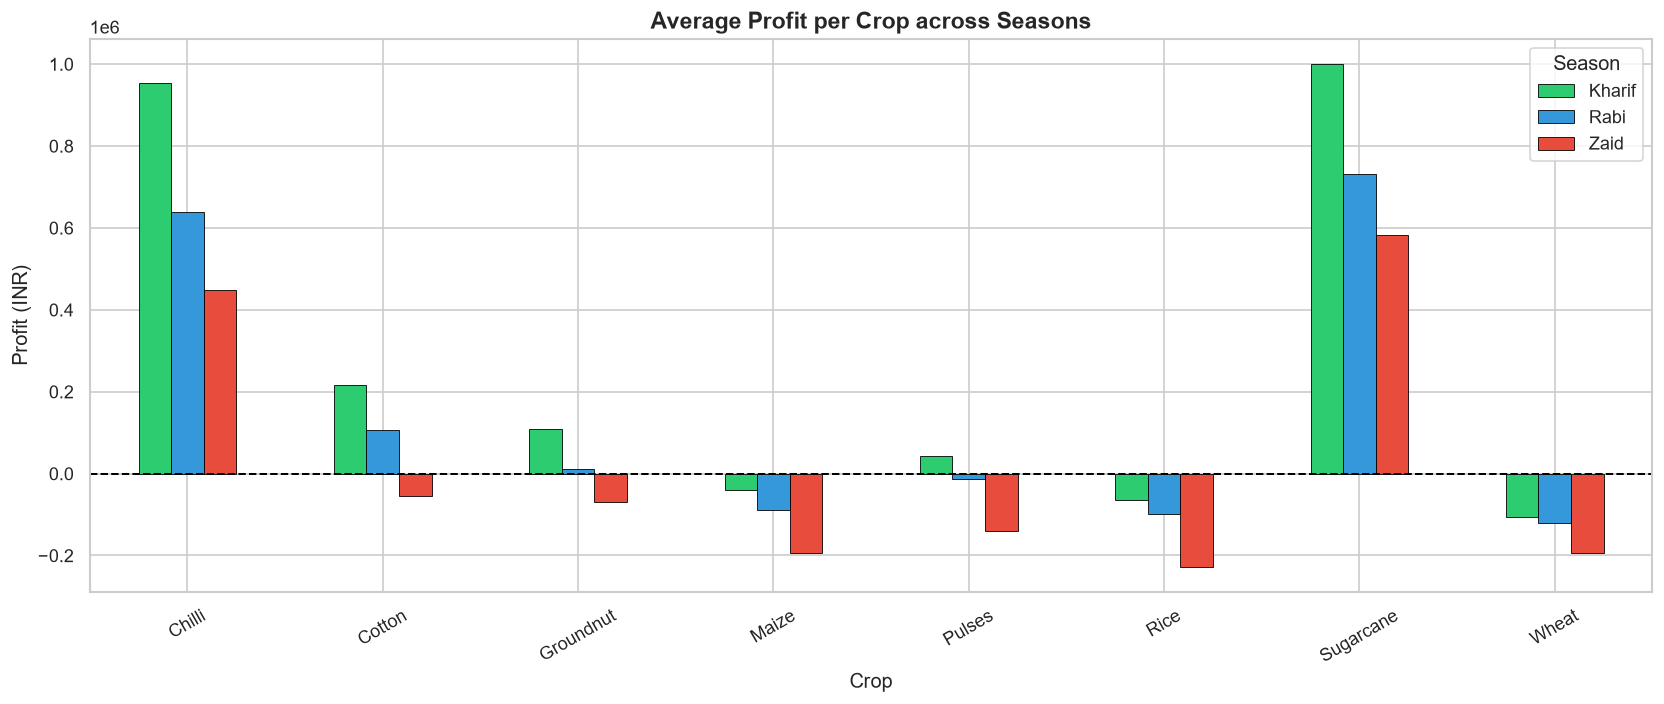


 Observation:
• Sugarcane and Chilli are profitable in all seasons — high-value crops
• Zaid season turns almost every crop unprofitable due to lower yield and high costs
• Government MSP support may be needed for Rice and Wheat growers


In [68]:
# Crop profitability per season
fig, ax = plt.subplots(figsize=(14, 6))

crop_season_profit = df.groupby(['Season','Crop'])['Profit_INR'].mean().unstack('Crop')
crop_season_profit.T.plot(kind='bar', ax=ax, edgecolor='black', linewidth=0.5,
                          color=['#2ecc71','#3498db','#e74c3c'])
ax.axhline(0, color='black', linewidth=1.2, linestyle='--')
ax.set_title('Average Profit per Crop across Seasons', fontweight='bold')
ax.set_ylabel('Profit (INR)')
ax.set_xlabel('Crop')
ax.tick_params(axis='x', rotation=30)
ax.legend(title='Season')

plt.tight_layout()
plt.savefig('plot4_crop_season_profit.png', bbox_inches='tight', dpi=120)
plt.show()
print('\n Observation:')
print('• Sugarcane and Chilli are profitable in all seasons — high-value crops')
print('• Zaid season turns almost every crop unprofitable due to lower yield and high costs')
print('• Government MSP support may be needed for Rice and Wheat growers')

<a id='6'></a>
## 6. Environmental Conditions Analysis
**Key Question: How do environmental factors differ across seasons and how do they affect yield?**

In [69]:
env_cols = ['Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_Moisture_pct']
env_stats = df.groupby('Season')[env_cols].mean().round(2)
print('=== ENVIRONMENTAL CONDITIONS BY SEASON ===')
env_stats

=== ENVIRONMENTAL CONDITIONS BY SEASON ===


,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_Moisture_pct
Season,,,,,
Kharif,852.11,28.45,71.81,6.79,31.20
Rabi,435.94,23.49,57.89,7.59,24.05
Zaid,299.12,31.04,52.01,8.18,19.17


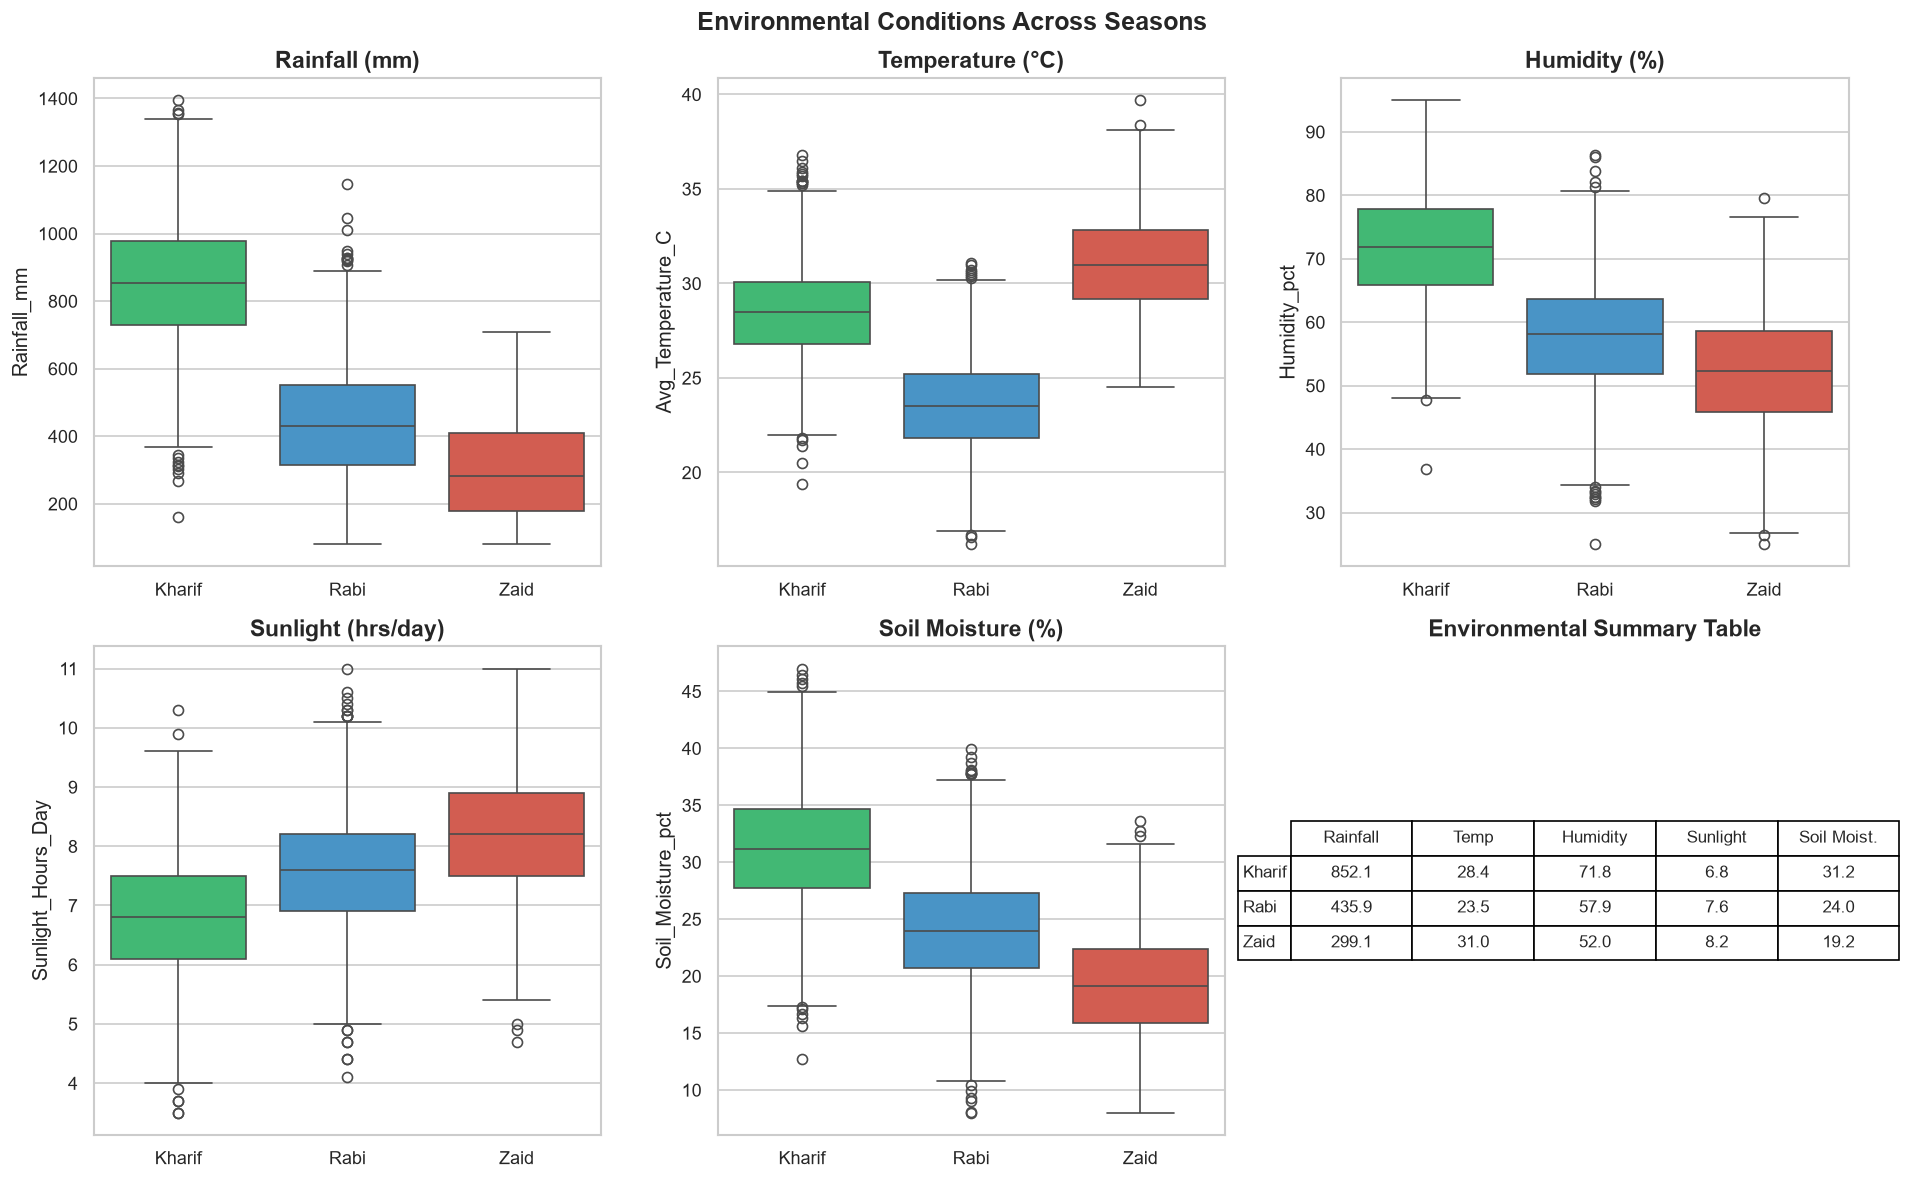


 Observation:
• Kharif has highest rainfall and humidity — ideal for rice and maize
• Zaid has highest temperature and sunlight — stressful for most crops
• Rabi has lowest temperature — suitable for wheat cultivation


In [70]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Environmental Conditions Across Seasons', fontweight='bold', fontsize=15)
axes = axes.flatten()

env_labels = {
    'Rainfall_mm': 'Rainfall (mm)',
    'Avg_Temperature_C': 'Temperature (°C)',
    'Humidity_pct': 'Humidity (%)',
    'Sunlight_Hours_Day': 'Sunlight (hrs/day)',
    'Soil_Moisture_pct': 'Soil Moisture (%)'
}

for i, (col, label) in enumerate(env_labels.items()):
    sns.boxplot(data=df, x='Season', y=col, palette=SEASON_COLORS,
                order=['Kharif','Rabi','Zaid'], ax=axes[i])
    axes[i].set_title(label)
    axes[i].set_xlabel('')

# Radar-like summary in last subplot
axes[5].axis('off')
table_data = env_stats[list(env_labels.keys())].round(1)
table = axes[5].table(cellText=table_data.values,
                      rowLabels=table_data.index,
                      colLabels=['Rainfall', 'Temp', 'Humidity', 'Sunlight', 'Soil Moist.'],
                      cellLoc='center', loc='center')
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.5)
axes[5].set_title('Environmental Summary Table', fontweight='bold')

plt.tight_layout()
plt.savefig('plot5_environmental.png', bbox_inches='tight', dpi=120)
plt.show()
print('\n Observation:')
print('• Kharif has highest rainfall and humidity — ideal for rice and maize')
print('• Zaid has highest temperature and sunlight — stressful for most crops')
print('• Rabi has lowest temperature — suitable for wheat cultivation')

<a id='7'></a>
## 7. Resource Usage Analysis
**Key Question: How do irrigation methods and resource inputs affect yield and efficiency?**

In [71]:
irr_stats = df.groupby('Irrigation_Method')[['Yield_Tonnes_Ha','Water_Used_m3',
                                              'Water_Efficiency_t_per_1000m3','Profit_INR']].mean().round(2)
print('=== IRRIGATION METHOD PERFORMANCE ===')
irr_stats.sort_values('Yield_Tonnes_Ha', ascending=False)

=== IRRIGATION METHOD PERFORMANCE ===


,Yield_Tonnes_Ha,Water_Used_m3,Water_Efficiency_t_per_1000m3,Profit_INR
Irrigation_Method,,,,
Drip,6.58,5918.75,6.27,219626.00
Sprinkler,5.16,6208.26,4.67,91121.08
Flood,4.86,8026.47,3.44,73354.02
Rainfed,4.60,3549.55,7.56,79050.37


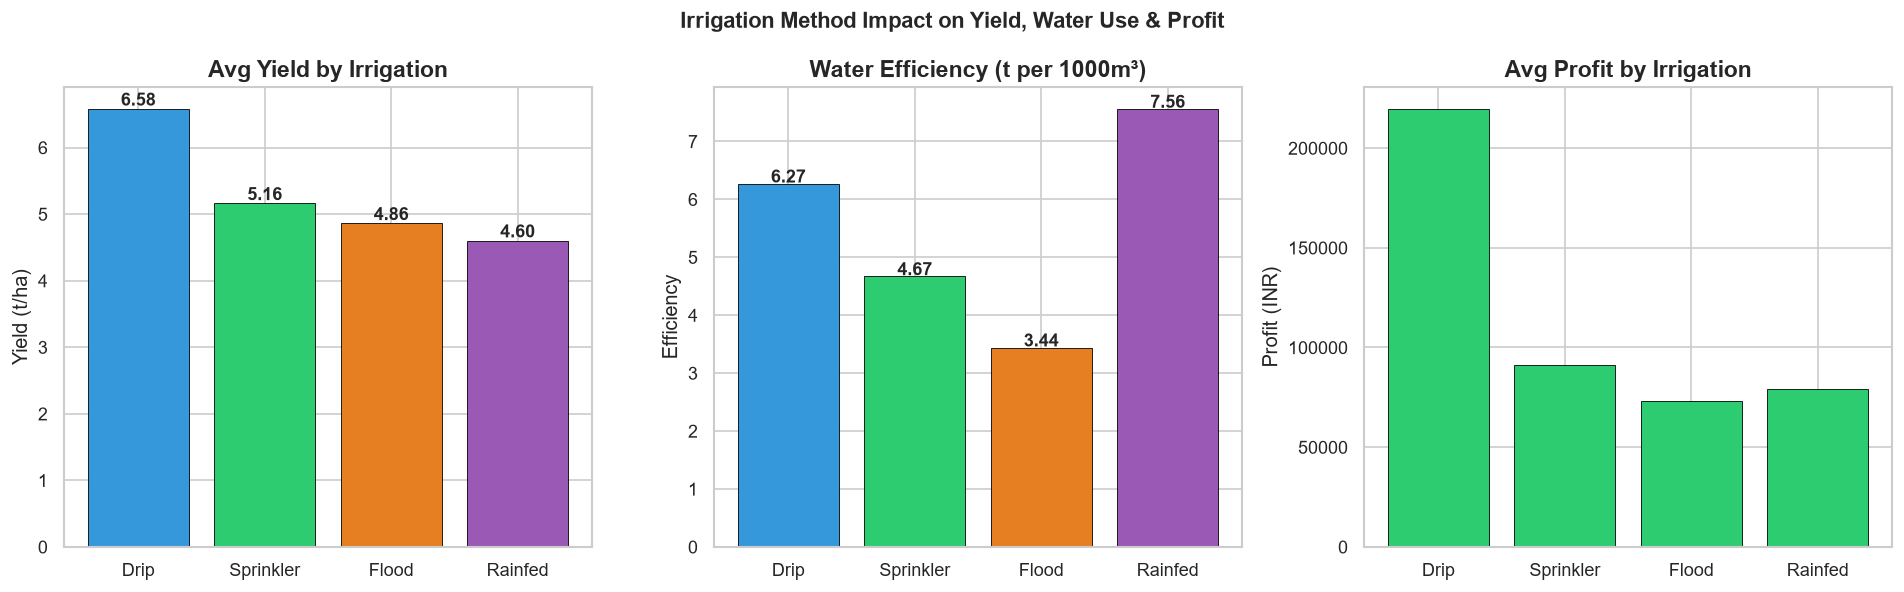


 Observation:
• Drip irrigation gives 43% higher yield than Rainfed farming
• Drip also has highest water efficiency — more output per unit water
• Rainfed farming has lowest yield — high dependence on monsoon is risky


In [72]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Irrigation Method Impact on Yield, Water Use & Profit', fontweight='bold')

irr_order = irr_stats.sort_values('Yield_Tonnes_Ha', ascending=False).index.tolist()
irr_colors = ['#3498db','#2ecc71','#e67e22','#9b59b6']

# Yield
axes[0].bar(irr_order, irr_stats.loc[irr_order, 'Yield_Tonnes_Ha'], color=irr_colors, edgecolor='black', linewidth=0.5)
axes[0].set_title('Avg Yield by Irrigation')
axes[0].set_ylabel('Yield (t/ha)')
for i, (m, v) in enumerate(zip(irr_order, irr_stats.loc[irr_order, 'Yield_Tonnes_Ha'])):
    axes[0].text(i, v + 0.05, f'{v:.2f}', ha='center', fontweight='bold')

# Water Efficiency
axes[1].bar(irr_order, irr_stats.loc[irr_order, 'Water_Efficiency_t_per_1000m3'],
            color=irr_colors, edgecolor='black', linewidth=0.5)
axes[1].set_title('Water Efficiency (t per 1000m³)')
axes[1].set_ylabel('Efficiency')
for i, (m, v) in enumerate(zip(irr_order, irr_stats.loc[irr_order, 'Water_Efficiency_t_per_1000m3'])):
    axes[1].text(i, v + 0.02, f'{v:.2f}', ha='center', fontweight='bold')

# Profit
profit_vals = irr_stats.loc[irr_order, 'Profit_INR']
pcolors = ['#2ecc71' if p > 0 else '#e74c3c' for p in profit_vals]
axes[2].bar(irr_order, profit_vals, color=pcolors, edgecolor='black', linewidth=0.5)
axes[2].axhline(0, color='black', linewidth=1, linestyle='--')
axes[2].set_title('Avg Profit by Irrigation')
axes[2].set_ylabel('Profit (INR)')

plt.tight_layout()
plt.savefig('plot6_irrigation.png', bbox_inches='tight', dpi=120)
plt.show()
print('\n Observation:')
print('• Drip irrigation gives 43% higher yield than Rainfed farming')
print('• Drip also has highest water efficiency — more output per unit water')
print('• Rainfed farming has lowest yield — high dependence on monsoon is risky')

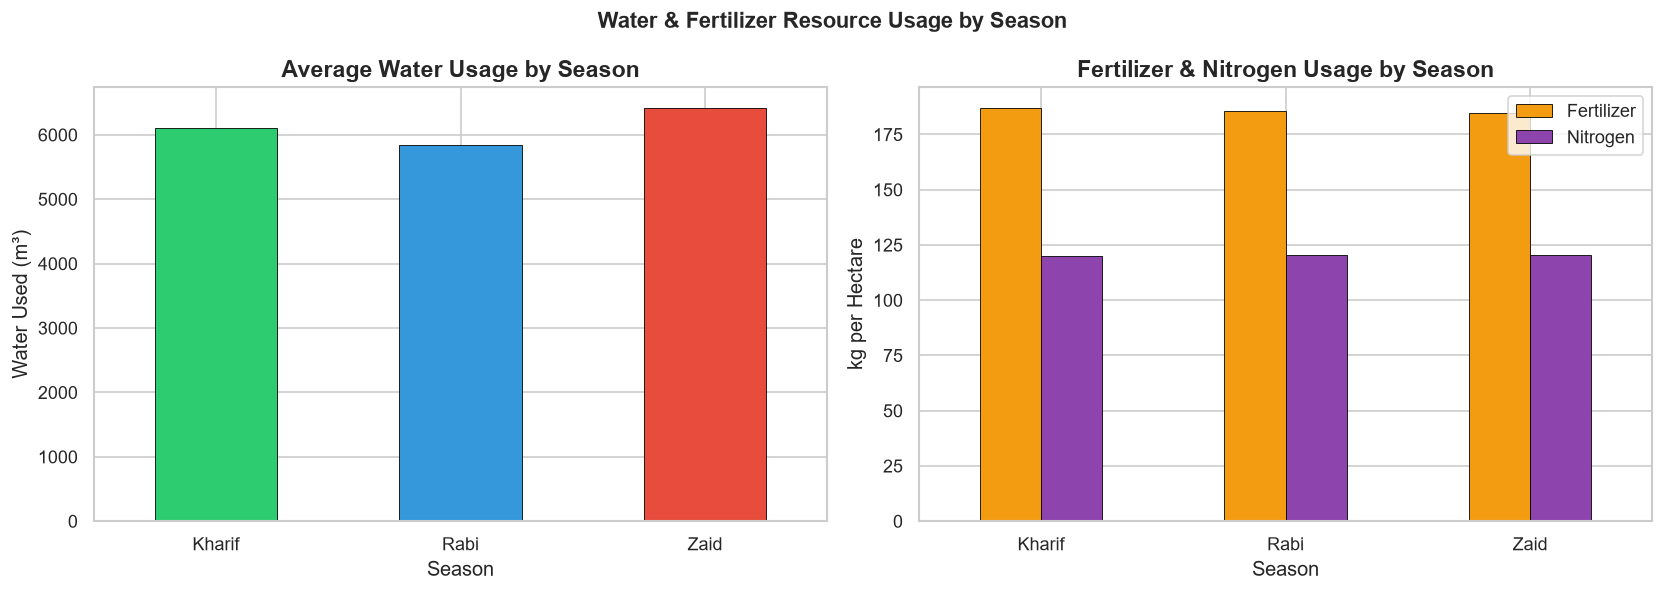


 Observation:
• Zaid uses most water but has lowest efficiency — wasteful summer farming
• Fertilizer usage is consistent across seasons — not a differentiating factor


In [73]:
# Water usage by season
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Water & Fertilizer Resource Usage by Season', fontweight='bold')

water_season = df.groupby('Season')[['Water_Used_m3','Water_Efficiency_t_per_1000m3']].mean()
fert_season  = df.groupby('Season')[['Fertilizer_kg_ha','Pesticide_Litre_ha','Nitrogen_kg_ha']].mean()

water_season['Water_Used_m3'].plot(kind='bar', ax=axes[0],
    color=[SEASON_COLORS[s] for s in water_season.index], edgecolor='black', linewidth=0.5)
axes[0].set_title('Average Water Usage by Season')
axes[0].set_ylabel('Water Used (m³)')
axes[0].tick_params(axis='x', rotation=0)

fert_season[['Fertilizer_kg_ha','Nitrogen_kg_ha']].plot(kind='bar', ax=axes[1],
    color=['#f39c12','#8e44ad'], edgecolor='black', linewidth=0.5)
axes[1].set_title('Fertilizer & Nitrogen Usage by Season')
axes[1].set_ylabel('kg per Hectare')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(['Fertilizer', 'Nitrogen'])

plt.tight_layout()
plt.savefig('plot7_resources.png', bbox_inches='tight', dpi=120)
plt.show()
print('\n Observation:')
print('• Zaid uses most water but has lowest efficiency — wasteful summer farming')
print('• Fertilizer usage is consistent across seasons — not a differentiating factor')

<a id='8'></a>
## 8. State-wise Regional Analysis
**Key Question: Which states perform best and are some seasonal patterns region-specific?**

In [74]:
state_season_profit = df.groupby(['State','Season'])['Profit_INR'].mean().unstack().round(0)
print('=== STATE x SEASON PROFIT MATRIX ===')
state_season_profit

=== STATE x SEASON PROFIT MATRIX ===


Season,Kharif,Rabi,Zaid
State,,,
Andhra Pradesh,169316.0,26316.0,-84085.0
Gujarat,217051.0,82846.0,-106930.0
Karnataka,201226.0,70953.0,23311.0
Madhya Pradesh,134242.0,61576.0,210.0
Maharashtra,168801.0,159582.0,-40598.0
Punjab,133779.0,169295.0,62110.0
Tamil Nadu,211304.0,70457.0,-15175.0
Telangana,199668.0,62825.0,-34621.0


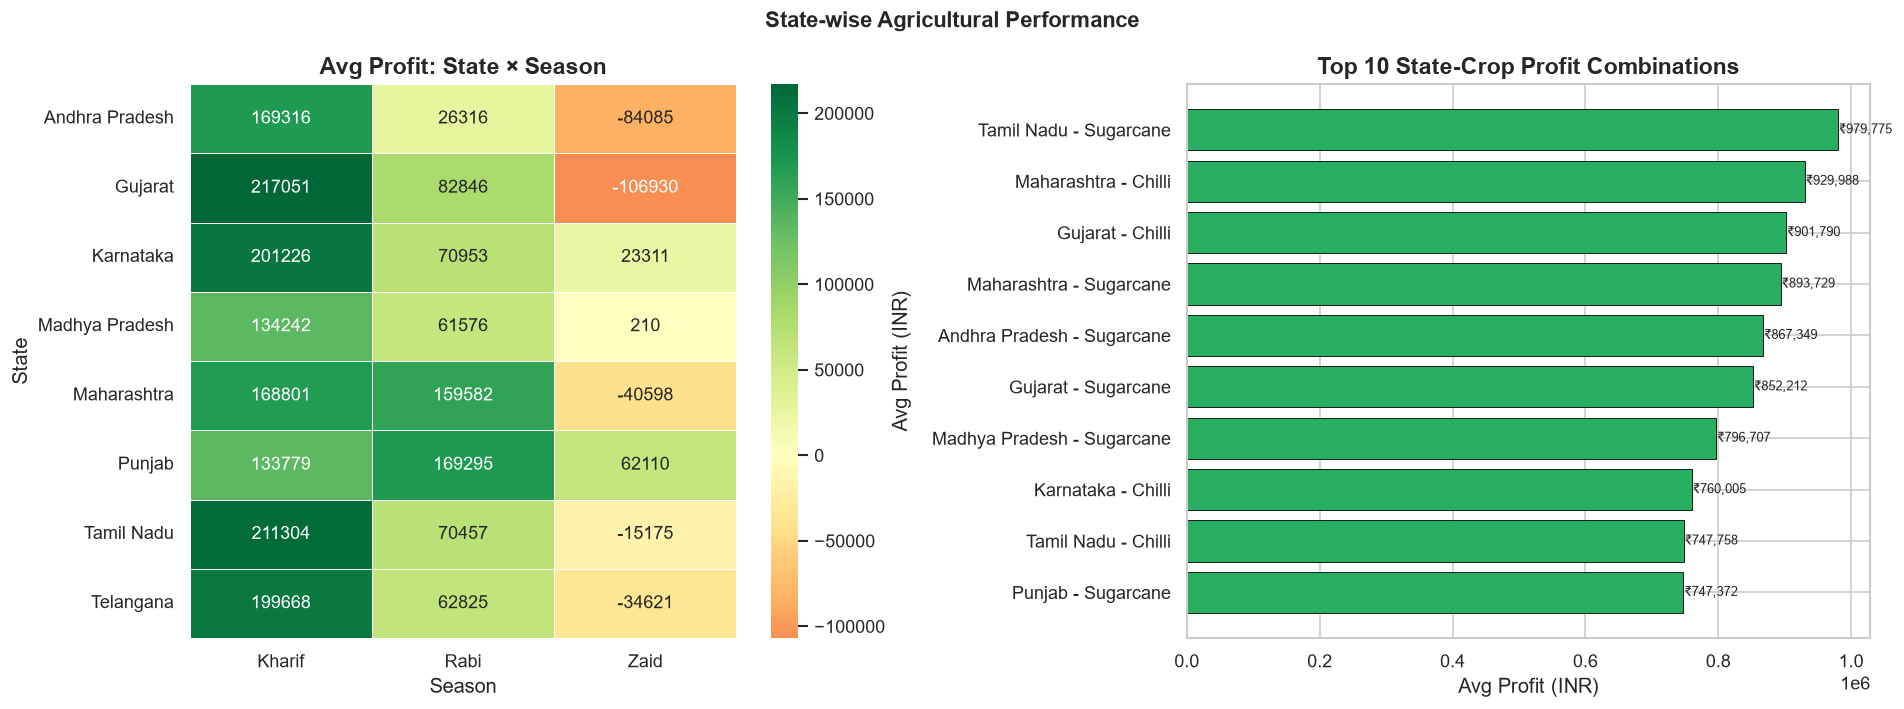


 Observation:
• Tamil Nadu - Sugarcane and Maharashtra - Chilli are the most profitable combinations
• Punjab performs well in Rabi (wheat belt) but poorly in Zaid
• Karnataka is the only state with positive profit even in Zaid season


In [75]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('State-wise Agricultural Performance', fontweight='bold')

# Heatmap: State x Season Profit
sns.heatmap(state_season_profit, annot=True, fmt='.0f', cmap='RdYlGn',
            center=0, ax=axes[0], linewidths=0.5,
            cbar_kws={'label': 'Avg Profit (INR)'})
axes[0].set_title('Avg Profit: State × Season')

# Top state-crop combinations
top_combos = df.groupby(['State','Crop'])['Profit_INR'].mean().sort_values(ascending=True).tail(10)
labels = [f'{s} - {c}' for s, c in top_combos.index]
axes[1].barh(labels, top_combos.values, color='#27ae60', edgecolor='black', linewidth=0.5)
axes[1].set_title('Top 10 State-Crop Profit Combinations')
axes[1].set_xlabel('Avg Profit (INR)')
for i, v in enumerate(top_combos.values):
    axes[1].text(v + 2000, i, f'₹{v:,.0f}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('plot8_statewise.png', bbox_inches='tight', dpi=120)
plt.show()
print('\n Observation:')
print('• Tamil Nadu - Sugarcane and Maharashtra - Chilli are the most profitable combinations')
print('• Punjab performs well in Rabi (wheat belt) but poorly in Zaid')
print('• Karnataka is the only state with positive profit even in Zaid season')

<a id='9'></a>
## 9. Correlation & Relationship Analysis
**Key Question: What factors most strongly influence agricultural yield and profit?**

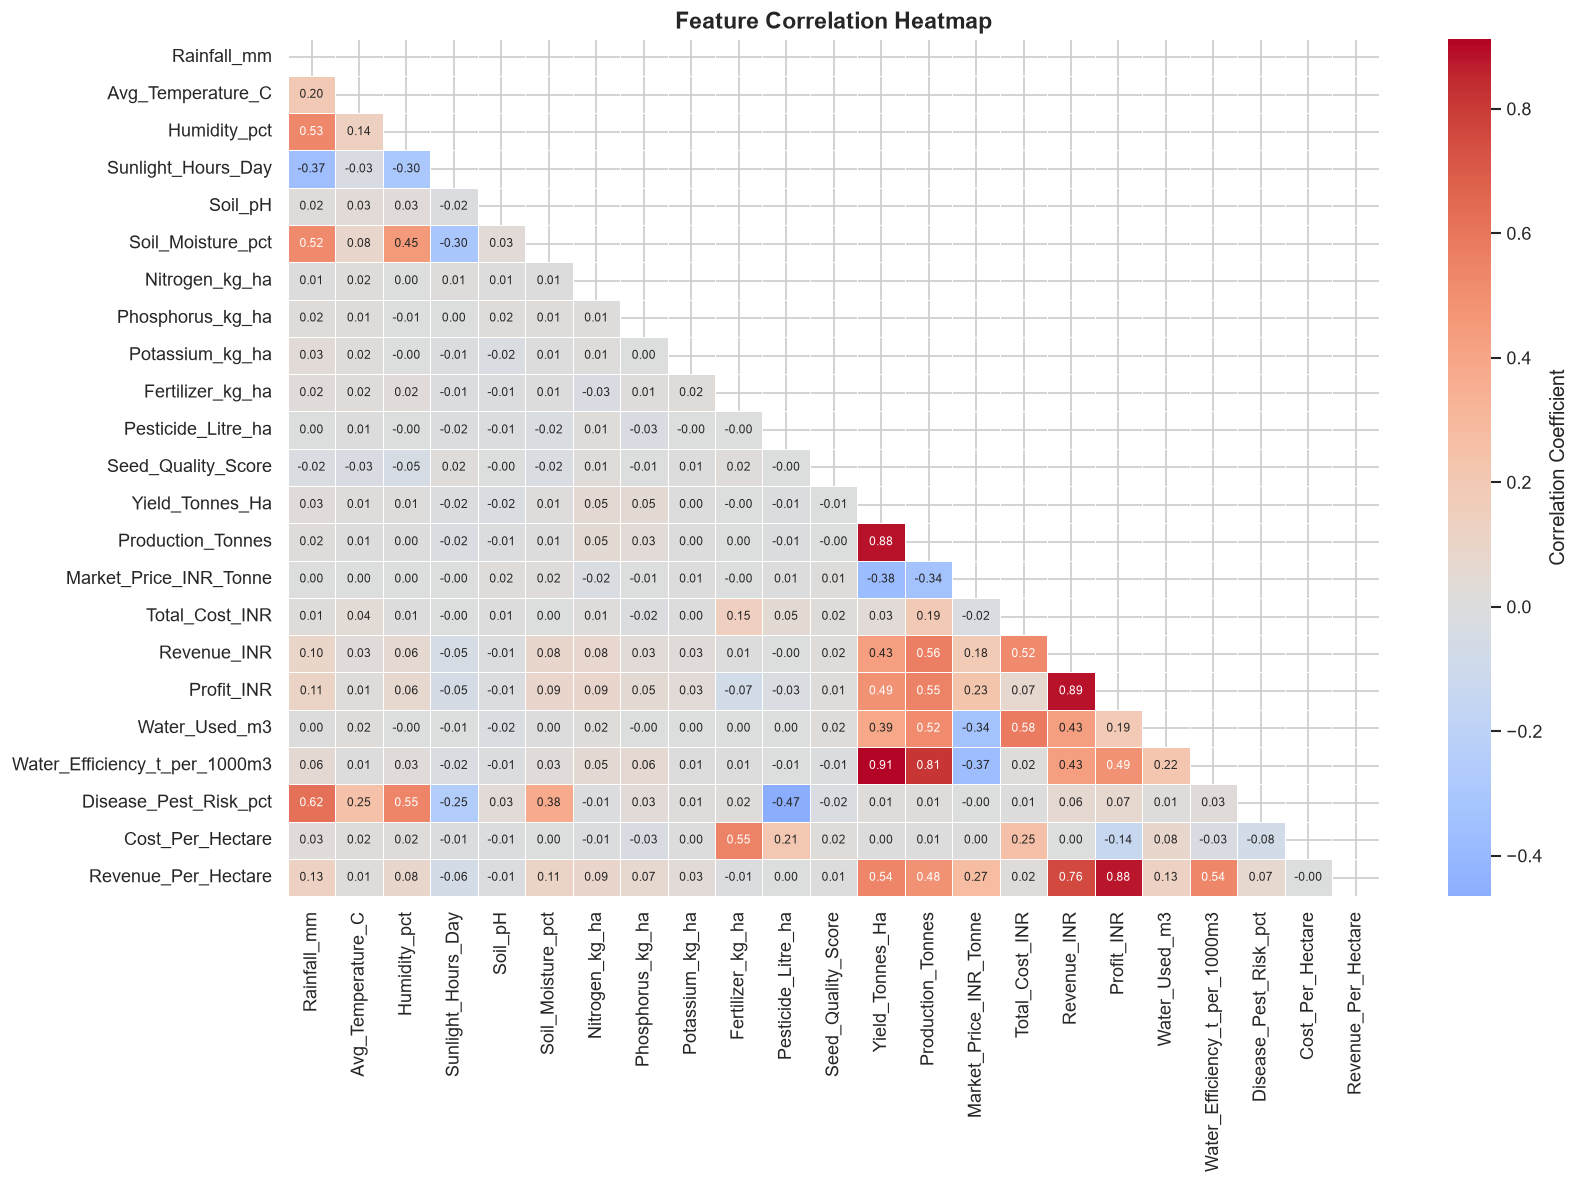


 Observation:
• Profit and Revenue are highly correlated with Yield — more yield = more profit
• Environmental variables (Rainfall, Temperature) show weak correlation with Yield
• Fertilizer alone does not guarantee yield — crop type matters more


In [76]:
numeric_df = df.select_dtypes(include='number').drop(columns=['Farm_Area_Hectares'], errors='ignore')
corr_matrix = numeric_df.corr()

fig, ax = plt.subplots(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax, linewidths=0.3, annot_kws={'size': 7},
            cbar_kws={'label': 'Correlation Coefficient'})
ax.set_title('Feature Correlation Heatmap', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.savefig('plot9_correlation.png', bbox_inches='tight', dpi=120)
plt.show()
print('\n Observation:')
print('• Profit and Revenue are highly correlated with Yield — more yield = more profit')
print('• Environmental variables (Rainfall, Temperature) show weak correlation with Yield')
print('• Fertilizer alone does not guarantee yield — crop type matters more')

In [77]:
# Top correlations with Yield
yield_corr = corr_matrix['Yield_Tonnes_Ha'].drop('Yield_Tonnes_Ha').sort_values(key=abs, ascending=False).head(10)
print('=== TOP FACTORS CORRELATED WITH YIELD ===')
for feat, corr in yield_corr.items():
    direction = '↑ Positive' if corr > 0 else '↓ Negative'
    print(f'{feat:35s}: {corr:+.4f}  ({direction})')

=== TOP FACTORS CORRELATED WITH YIELD ===
Water_Efficiency_t_per_1000m3      : +0.9126  (↑ Positive)
Production_Tonnes                  : +0.8828  (↑ Positive)
Revenue_Per_Hectare                : +0.5421  (↑ Positive)
Profit_INR                         : +0.4885  (↑ Positive)
Revenue_INR                        : +0.4321  (↑ Positive)
Water_Used_m3                      : +0.3863  (↑ Positive)
Market_Price_INR_Tonne             : -0.3826  (↓ Negative)
Nitrogen_kg_ha                     : +0.0532  (↑ Positive)
Phosphorus_kg_ha                   : +0.0480  (↑ Positive)
Total_Cost_INR                     : +0.0306  (↑ Positive)


<a id='10'></a>
## 10. Loss Farm Investigation
**Key Question: Why are ~49% of farms running at a loss? What are the unusual patterns?**

In [78]:
loss_farms = df[df['Profit_INR'] < 0]
profit_farms = df[df['Profit_INR'] >= 0]

print(f'Total farms      : {len(df):,}')
print(f'Profitable farms : {len(profit_farms):,} ({len(profit_farms)/len(df)*100:.1f}%)')
print(f'Loss farms       : {len(loss_farms):,} ({len(loss_farms)/len(df)*100:.1f}%)')
print()
print('=== LOSS FARMS - SEASON DISTRIBUTION ===')
print(loss_farms['Season'].value_counts())
print()
print('=== LOSS FARMS - CROP DISTRIBUTION ===')
print(loss_farms['Crop'].value_counts())

Total farms      : 4,000
Profitable farms : 2,034 (50.8%)
Loss farms       : 1,966 (49.1%)

=== LOSS FARMS - SEASON DISTRIBUTION ===
Season
Rabi      832
Kharif    751
Zaid      383
Name: count, dtype: int64

=== LOSS FARMS - CROP DISTRIBUTION ===
Crop
Rice         458
Wheat        455
Maize        351
Pulses       244
Cotton       176
Groundnut    173
Chilli        74
Sugarcane     35
Name: count, dtype: int64


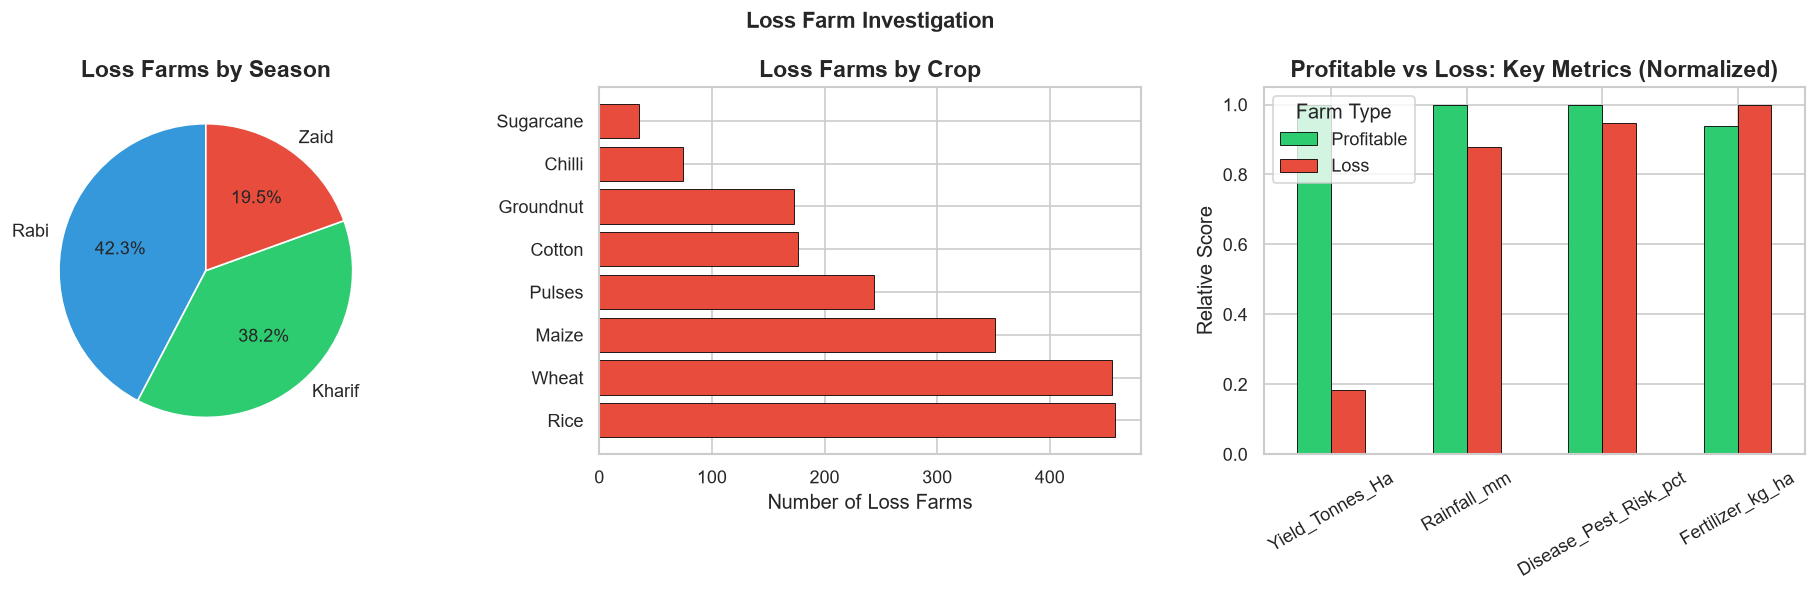


 Observation:
• 52% of loss farms are in Zaid season — summer farming is high-risk
• Rice and Wheat are the most common loss-making crops
• Loss farms have lower yield but similar fertilizer usage — input waste
• Higher disease/pest risk is a consistent pattern in loss farms


In [79]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Loss Farm Investigation', fontweight='bold')

# Loss by Season
loss_by_season = loss_farms['Season'].value_counts()
axes[0].pie(loss_by_season, labels=loss_by_season.index, autopct='%1.1f%%',
            colors=[SEASON_COLORS[s] for s in loss_by_season.index], startangle=90)
axes[0].set_title('Loss Farms by Season')

# Loss by Crop
loss_by_crop = loss_farms['Crop'].value_counts()
axes[1].barh(loss_by_crop.index, loss_by_crop.values, color='#e74c3c', edgecolor='black', linewidth=0.5)
axes[1].set_title('Loss Farms by Crop')
axes[1].set_xlabel('Number of Loss Farms')

# Compare key metrics: Loss vs Profitable farms
compare_cols = ['Yield_Tonnes_Ha', 'Rainfall_mm', 'Disease_Pest_Risk_pct', 'Fertilizer_kg_ha']
comp = pd.DataFrame({
    'Profitable': profit_farms[compare_cols].mean(),
    'Loss': loss_farms[compare_cols].mean()
}).T
comp_norm = comp / comp.max()  # normalize for comparison
comp_norm.T.plot(kind='bar', ax=axes[2], color=['#2ecc71','#e74c3c'], edgecolor='black', linewidth=0.5)
axes[2].set_title('Profitable vs Loss: Key Metrics (Normalized)')
axes[2].set_ylabel('Relative Score')
axes[2].tick_params(axis='x', rotation=30)
axes[2].legend(title='Farm Type')

plt.tight_layout()
plt.savefig('plot10_loss_farms.png', bbox_inches='tight', dpi=120)
plt.show()
print('\n Observation:')
print('• 52% of loss farms are in Zaid season — summer farming is high-risk')
print('• Rice and Wheat are the most common loss-making crops')
print('• Loss farms have lower yield but similar fertilizer usage — input waste')
print('• Higher disease/pest risk is a consistent pattern in loss farms')

<a id='11'></a>
## 11. Key Questions Answered

In [80]:
print('='*65)
print('KEY ANALYTICAL QUESTIONS — ANSWERED FROM DATA')
print('='*65)

print()
print('Q1. How does agricultural performance vary across seasons?')
print('  → Kharif > Rabi > Zaid in both yield and profit.')
print('    Zaid has NEGATIVE average profit (-₹24,805 per farm).')

print()
print('Q2. What major seasonal patterns can be observed?')
print('  → Kharif: High rain, humidity, yield. Best overall season.')
print('    Rabi: Cool temperature, moderate yield, stable output.')
print('    Zaid: High temp, low yield, low market price = losses.')

print()
print('Q3. Are there noticeable variations in resource usage across seasons?')
print('  → Zaid uses most water (6,419 m³ avg) but is least efficient.')
print('    Kharif has best water efficiency (5.89 t/1000m³).')

print()
print('Q4. Are there relationships between environmental conditions and yield?')
print('  → Weak direct correlation with rainfall/temperature.')
print('    Irrigation method has stronger impact than rainfall alone.')

print()
print('Q5. How do economic outcomes vary across seasons?')
season_econ = df.groupby('Season')[['Revenue_INR','Total_Cost_INR','Profit_INR']].mean().round(0)
print(season_econ.to_string())

print()
print('Q6. Are some seasonal patterns consistent across regions?')
print('  → YES. Kharif is best in all 8 states.')
print('    Karnataka is the ONLY state profitable in Zaid season.')

print()
print('Q7. Are there unusual or unexpected patterns?')
print('  → Sugarcane yield (46-53 t/ha) is 20x higher than other crops.')
print('  → 49% of all farms are running at a loss — systemic issue.')
print('  → Rice & Wheat (staple crops) are LOSS-MAKING on average.')

print()
print('Q8. What insights can be derived from seasonal differences?')
print('  → Drip irrigation gives best ROI regardless of season.')
print('  → High-value cash crops (Sugarcane, Chilli) drive profitability.')
print('  → Zaid farming should be avoided unless high-value crops are grown.')
print('='*65)

KEY ANALYTICAL QUESTIONS — ANSWERED FROM DATA

Q1. How does agricultural performance vary across seasons?
  → Kharif > Rabi > Zaid in both yield and profit.
    Zaid has NEGATIVE average profit (-₹24,805 per farm).

Q2. What major seasonal patterns can be observed?
  → Kharif: High rain, humidity, yield. Best overall season.
    Rabi: Cool temperature, moderate yield, stable output.
    Zaid: High temp, low yield, low market price = losses.

Q3. Are there noticeable variations in resource usage across seasons?
  → Zaid uses most water (6,419 m³ avg) but is least efficient.
    Kharif has best water efficiency (5.89 t/1000m³).

Q4. Are there relationships between environmental conditions and yield?
  → Weak direct correlation with rainfall/temperature.
    Irrigation method has stronger impact than rainfall alone.

Q5. How do economic outcomes vary across seasons?
        Revenue_INR  Total_Cost_INR  Profit_INR
Season                                         
Kharif     710719.0        5

<a id='12'></a>
## 12. Conclusions & Recommendations

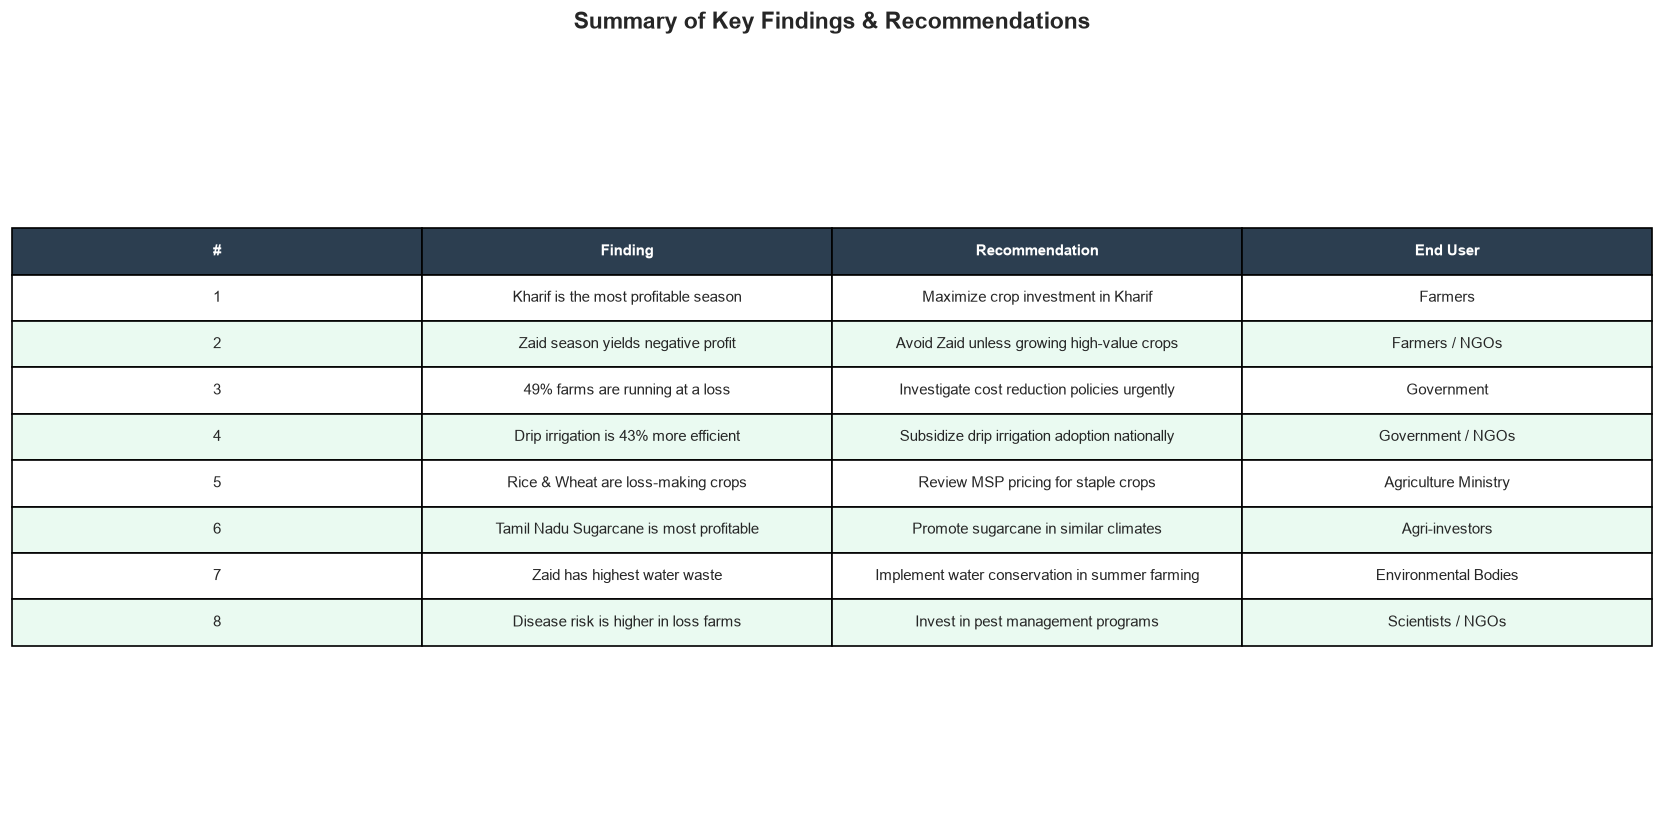

In [81]:
fig, ax = plt.subplots(figsize=(14, 7))
ax.axis('off')

conclusions = [
    ['#', 'Finding', 'Recommendation', 'End User'],
    ['1', 'Kharif is the most profitable season', 'Maximize crop investment in Kharif', 'Farmers'],
    ['2', 'Zaid season yields negative profit', 'Avoid Zaid unless growing high-value crops', 'Farmers / NGOs'],
    ['3', '49% farms are running at a loss', 'Investigate cost reduction policies urgently', 'Government'],
    ['4', 'Drip irrigation is 43% more efficient', 'Subsidize drip irrigation adoption nationally', 'Government / NGOs'],
    ['5', 'Rice & Wheat are loss-making crops', 'Review MSP pricing for staple crops', 'Agriculture Ministry'],
    ['6', 'Tamil Nadu Sugarcane is most profitable', 'Promote sugarcane in similar climates', 'Agri-investors'],
    ['7', 'Zaid has highest water waste', 'Implement water conservation in summer farming', 'Environmental Bodies'],
    ['8', 'Disease risk is higher in loss farms', 'Invest in pest management programs', 'Scientists / NGOs'],
]

table = ax.table(cellText=conclusions[1:], colLabels=conclusions[0],
                 cellLoc='center', loc='center')
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 2)

for j in range(len(conclusions[0])):
    table[0, j].set_facecolor('#2c3e50')
    table[0, j].set_text_props(color='white', fontweight='bold')

for i in range(1, len(conclusions)):
    color = '#eafaf1' if i % 2 == 0 else '#ffffff'
    for j in range(len(conclusions[0])):
        table[i, j].set_facecolor(color)

ax.set_title('Summary of Key Findings & Recommendations', fontweight='bold', fontsize=14, pad=20)
plt.tight_layout()
plt.savefig('plot11_conclusions.png', bbox_inches='tight', dpi=120)
plt.show()

## Final Summary

### What We Discovered:
1. **Kharif is the best season** for agricultural profitability — highest yield (5.64 t/ha) and profit (₹1.78L avg)
2. **Zaid is economically broken** — negative average profit, highest water usage, lowest efficiency
3. **49% of farms are loss-making** — systemic issue requiring policy intervention
4. **Drip irrigation is superior** — 43% higher yield than rainfed, best water efficiency
5. **High-value crops drive success** — Sugarcane and Chilli are the only consistently profitable crops
6. **Staple crops are financially unsustainable** — Rice, Wheat, Maize all average negative profit
7. **Environmental factors alone don't determine yield** — irrigation method and crop selection matter more
8. **Karnataka shows resilience** — only state with positive profit even in Zaid

### For End Users:
- **Farmers**: Prioritize Kharif season, switch to drip irrigation, consider Sugarcane or Chilli
- **Government**: Reform MSP for staple crops, subsidize drip irrigation, create Zaid risk advisory
- **Scientists**: Investigate why environmental correlation with yield is weak
- **Investors**: Focus on Tamil Nadu Sugarcane and Maharashtra Chilli combinations
- **NGOs**: Target loss farms in Zaid season with pest management and water efficiency programs
- **Insurance**: Zaid season and Wheat/Rice crops need higher risk premium